In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid import make_radial_grid, cell_centers, shell_volumes, log_cell_centers, log_shell_volumes
from initial_conditions import nfw_dimensionless, truncated_nfw_dimensionless, enclosed_mass, shell_mass, hydrostatic_u_from_rho
from residual import hydrostatic_residual, hydrostatic_terms_and_scale

In [2]:
r_first=0.001
r_max=70.0
N_shell=200

In [3]:
r_edge = make_radial_grid(r_first, r_max, N_shell)
r = cell_centers(r_edge)
V = shell_volumes(r_edge)

In [4]:
ln_r_edge = np.log(r_edge)
ln_r = log_cell_centers(ln_r_edge)
ln_V = log_shell_volumes(ln_r_edge)

/var/folders/sq/wmftrzfs7fn7mp6d45b04pm80000gn/T/ipykernel_54322/1899595485.py:1: RuntimeWarning: divide by zero encountered in log
  ln_r_edge = np.log(r_edge)


In [5]:
r_edge.dtype, r.dtype, V.dtype, ln_r.dtype, ln_V.dtype

(dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'))

In [6]:
r_t=40.0
n=5.0
rho = nfw_dimensionless(r)
dm = shell_mass(rho, V)
M_edge = enclosed_mass(dm)
u = hydrostatic_u_from_rho(r_edge, rho, M_edge, u_outer=0.01)

In [7]:
rho.dtype, dm.dtype, M_edge.dtype, u.dtype

(dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'))

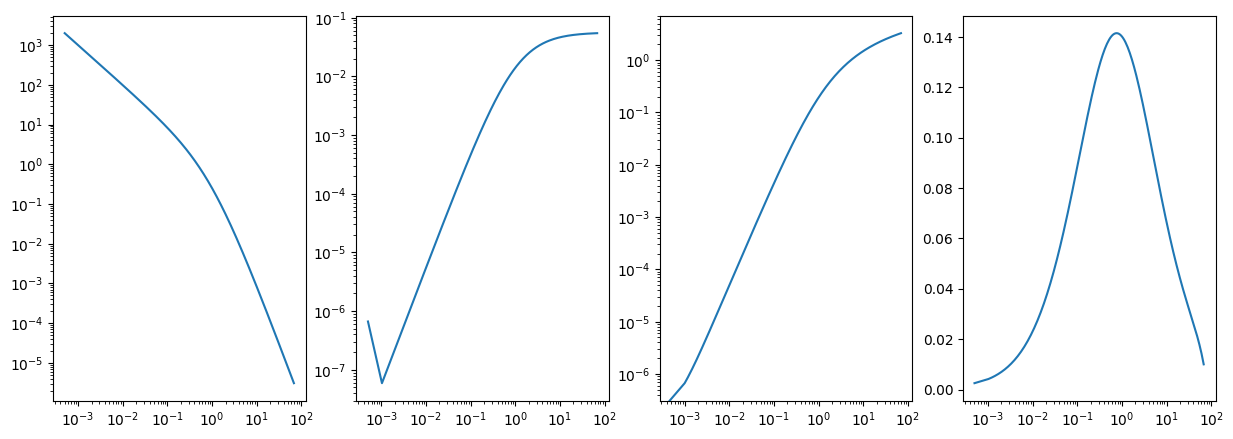

In [8]:
fig,ax=plt.subplots(1,4,figsize=(15,5),sharex='all')
ax[0].plot(r,rho)
ax[1].plot(r,dm)
ax[2].plot(r_edge,M_edge)
ax[3].plot(r,u)

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[2].set_yscale('log')

In [9]:
ln_rho = np.log(rho)
F_H, scaled_F_H = hydrostatic_residual(ln_r_edge, u, ln_rho, M_edge)

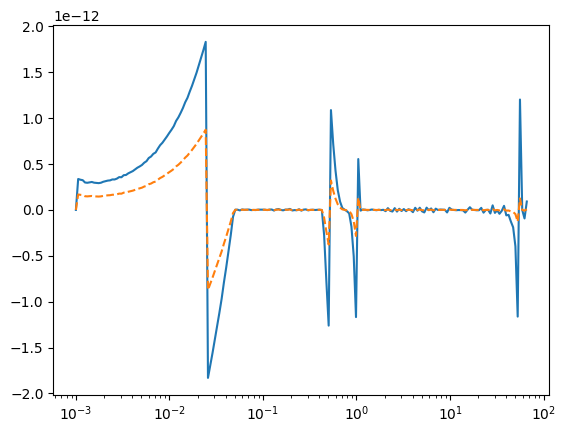

In [10]:
fig,ax=plt.subplots()
ax.plot(r_edge[1:-1], F_H)
ax.plot(r_edge[1:-1], scaled_F_H,ls='--')
ax.set_xscale('log')

In [11]:
rho_slope, u_slope, gravity_slope, hydro_scale = hydrostatic_terms_and_scale(ln_r_edge, u, ln_rho, M_edge)

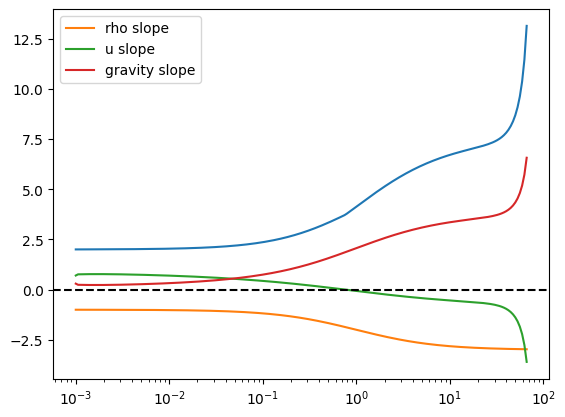

In [16]:
fig, ax =  plt.subplots()

ax.plot(r_edge[1:-1],hydro_scale)

ax.plot(r_edge[1:-1],rho_slope,label='rho slope')
ax.plot(r_edge[1:-1],u_slope,label='u slope')

ax.plot(r_edge[1:-1],gravity_slope,label='gravity slope')

ax.axhline(y=0,ls='--',color='black')

ax.legend()
ax.set_xscale('log')